In [1]:
# 加载数据
import torch
from joblib import dump, load
import torch.utils.data as Data
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载数据集
def dataloader(batch_size, workers=2):
    # 训练集
    train_set = load('../dataresult/train_set')
    train_label = load('../dataresult/train_label')
    # 测试集
    test_set = load('../dataresult/test_set')
    test_label = load('../dataresult/test_label')

    # 加载数据
    train_loader = Data.DataLoader(dataset=Data.TensorDataset(train_set, train_label),
                                   batch_size=batch_size, num_workers=workers, drop_last=True)
    test_loader = Data.DataLoader(dataset=Data.TensorDataset(test_set, test_label),
                                  batch_size=batch_size, num_workers=workers, drop_last=True)
    return train_loader, test_loader

batch_size = 32
# 加载数据
train_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(test_loader))

114
73


In [2]:
# 定义 Transformer 模型
from torch.nn import Transformer, TransformerEncoder, TransformerEncoderLayer

class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_heads, output_dim, dropout_rate=0.5):
        """
        params:
        input_dim          : 输入数据的维度
        hidden_dim         : 注意力维度
        num_layers         : Transformer编码器层数
        num_heads          : 多头注意力头数
        output_dim         : 输出维度
        dropout_rate        : 随机丢弃神经元的概率
        """
        super().__init__()
         # 上采样操作
        self.unsampling = nn.Conv1d(input_dim, 32, 1)

        # 参数
        self.output_dim = output_dim

        # Transformer编码器
        self.hidden_dim = hidden_dim
        # Time Transformer layers
        self.transformer = TransformerEncoder(
            TransformerEncoderLayer(32, num_heads, hidden_dim, dropout=dropout_rate, batch_first=True),
            num_layers
        )

        # 序列平局池化
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # 定义线性层
        self.linear  = nn.Linear(32, output_dim)


    def forward(self, input_seq):
        batch_size = input_seq.size(0)
        # 预处理  先进行上采样
        unsampling = self.unsampling(input_seq.permute(0,2,1))  
        # Time-Transformer 处理
        # 在PyTorch中，transformer模型的性能与batch_first参数的设置相关。
        # 当batch_first为True时，输入的形状应为(batch, sequence, feature)，这种设置在某些情况下可以提高推理性能。
        transformer_output = self.transformer(unsampling.permute(0,2,1))  #  torch.Size([32, 1, 32])
        # 序列平均池化操作
        output_avgpool = self.avgpool(transformer_output.transpose(1, 2))  #  torch.Size([32, 32, 1])
        output_avgpool = output_avgpool.reshape(batch_size, -1)  #  torch.Size([32, 32])
        predict = self.linear(output_avgpool) 
        return predict

In [3]:
# 定义模型参数
input_dim = 14    # 输入维度为 14 个维度
# Transformer参数
hidden_dim = 128  # 注意力维度
num_layers = 2  # 编码器层数
num_heads = 2   # 多头注意力头数
output_dim = 1   # 输出维度 为1

model = TransformerModel(input_dim, hidden_dim, num_layers, num_heads, output_dim)  

# 定义损失函数和优化函数 
loss_function = nn.MSELoss()  # loss
learn_rate = 0.0003
optimizer = torch.optim.Adam(model.parameters(), learn_rate)  # 优化器


# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

   448
    32
  3072
    96
  1024
    32
  4096
   128
  4096
    32
    32
    32
    32
    32
  3072
    96
  1024
    32
  4096
   128
  4096
    32
    32
    32
    32
    32
    32
     1
______
 25921


In [4]:
print(model)

TransformerModel(
  (unsampling): Conv1d(14, 32, kernel_size=(1,), stride=(1,))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.5, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.5, inplace=False)
        (dropout2): Dropout(p=0.5, inplace=False)
      )
    )
  )
  (avgpool): AdaptiveAvgPool1d(output_size=1)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)


e:\Anaconda\anaconda\envs\yolo\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Epoch:  1 train_MSE-Loss: 0.59690883
Epoch:  2 train_MSE-Loss: 0.05052049
Epoch:  3 train_MSE-Loss: 0.06401342
Epoch:  4 train_MSE-Loss: 0.10356398
Epoch:  5 train_MSE-Loss: 0.11690698
Epoch:  6 train_MSE-Loss: 0.09241766
Epoch:  7 train_MSE-Loss: 0.06333833
Epoch:  8 train_MSE-Loss: 0.04375758
Epoch:  9 train_MSE-Loss: 0.03348517
Epoch: 10 train_MSE-Loss: 0.02805541
Epoch: 11 train_MSE-Loss: 0.02399719
Epoch: 12 train_MSE-Loss: 0.02032947
Epoch: 13 train_MSE-Loss: 0.01781660
Epoch: 14 train_MSE-Loss: 0.01815557
Epoch: 15 train_MSE-Loss: 0.01921462
Epoch: 16 train_MSE-Loss: 0.02027136
Epoch: 17 train_MSE-Loss: 0.01931627
Epoch: 18 train_MSE-Loss: 0.01743716
Epoch: 19 train_MSE-Loss: 0.01679140
Epoch: 20 train_MSE-Loss: 0.01519109
Epoch: 21 train_MSE-Loss: 0.01345558
Epoch: 22 train_MSE-Loss: 0.01313278
Epoch: 23 train_MSE-Loss: 0.01204661
Epoch: 24 train_MSE-Loss: 0.01112871
Epoch: 25 train_MSE-Loss: 0.01084766
Epoch: 26 train_MSE-Loss: 0.01204738
Epoch: 27 train_MSE-Loss: 0.01149641
E

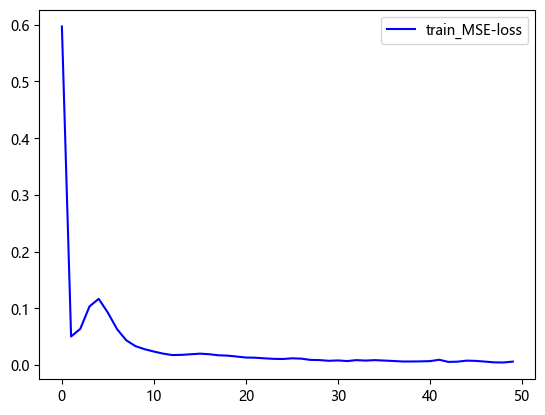

min_MSE: 0.004735744077806247


In [5]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

def model_train(epochs, model, optimizer, loss_function, train_loader, device):
    model = model.to(device)

    # 最低MSE  
    minimum_mse = 1000.
    # 最佳模型
    best_model = model

    train_mse = []     # 记录在训练集上每个epoch的 MSE 指标的变化情况   平均值
  
    # 计算模型运行时间
    start_time = time.time()
    for epoch in range(epochs):
         # 训练
        model.train()
        train_mse_loss = []    #保存当前epoch的MSE loss和
        for seq, labels in train_loader: 
            seq, labels = seq.to(device), labels.to(device)
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(seq)  #   torch.Size([16, 10])
            # 损失计算
            loss = loss_function(y_pred, labels)
            train_mse_loss.append(loss.item()) # 计算 MSE 损失
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
        #     break
        # break
        # 计算总损失
        train_av_mseloss = np.average(train_mse_loss) # 平均
        train_mse.append(train_av_mseloss)
        print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')
       
        # 如果当前模型的 MSE 低于于之前的最佳准确率，则更新最佳模型
        #保存当前最优模型参数
        if train_av_mseloss < minimum_mse:
            minimum_mse = train_av_mseloss
            best_model = model# 更新最佳模型的参数
         
    # 保存最后的参数
    # torch.save(model, 'final_model_transformer.pt')
    # 保存最好的参数
    torch.save(best_model, 'best_model_transformer.pt')
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    
    # 可视化
    plt.plot(range(epochs), train_mse, color = 'b',label = 'train_MSE-loss')
    plt.legend()
    plt.show()   #显示 lable 
    print(f'min_MSE: {minimum_mse}')

#  模型训练
epochs = 50
model_train(epochs, model, optimizer, loss_function, train_loader, device)

### 第一部分，训练集评估

In [6]:
# 模型预测
# 模型 测试集 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_transformer.pt')
model = model.to(device)

# 预测数据
origin_data = []
pre_data = []
with torch.no_grad():
        for data, label in train_loader:
            # 原始标签
            origin_lable = label.tolist()
            origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            train_pred = model(data)  # 对测试集进行预测
            train_pred = train_pred.tolist()
            pre_data += train_pred      

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
origin_data = scaler.inverse_transform(origin_data)
pre_data = scaler.inverse_transform(pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(origin_data, pre_data)
print('训练集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
train_mse = mean_squared_error(origin_data, pre_data)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(origin_data, pre_data)
print('训练数据集上的均方误差-MSE: ',train_mse)
print('训练数据集上的均方根误差-RMSE: ',train_rmse)
print('训练数据集上的平均绝对误差-MAE: ',train_mae)

训练集上 模型分数-R^2: 0.9738573078827224
**************************************************
训练数据集上的均方误差-MSE:  0.0021480916844257743
训练数据集上的均方根误差-RMSE:  0.046347510013222654
训练数据集上的平均绝对误差-MAE:  0.03897536284645099


# 测试集评估

In [11]:
# 模型 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_transformer.pt')
model = model.to(device)

# 预测数据
test_origin_data = []
test__pre_data = []
with torch.no_grad():
        for data, label in test_loader:
            # 原始标签
            origin_lable = label.tolist()
            test_origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            pred = model(data)  # 对测试集进行预测
            pred = pred.tolist()
            test__pre_data += pred        

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# 反归一化处理
# 使用相同的均值和标准差对预测结果进行反归一化处理
# 反标准化
scaler  = load('../dataresult/scaler')
test_origin_data = scaler.inverse_transform(test_origin_data)
test__pre_data = scaler.inverse_transform(test__pre_data)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(test_origin_data, test__pre_data)
print('测试集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
test_mse = mean_squared_error(test_origin_data, test__pre_data)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_origin_data, test__pre_data)
print('测试数据集上的均方误差-MSE: ',test_mse)
print('测试数据集上的均方根误差-RMSE: ',test_rmse)
print('测试数据集上的平均绝对误差-MAE: ',test_mae)

测试集上 模型分数-R^2: 0.9866956779691067
**************************************************
测试数据集上的均方误差-MSE:  0.001072580437862554
测试数据集上的均方根误差-RMSE:  0.03275027385935199
测试数据集上的平均绝对误差-MAE:  0.02758164434834313


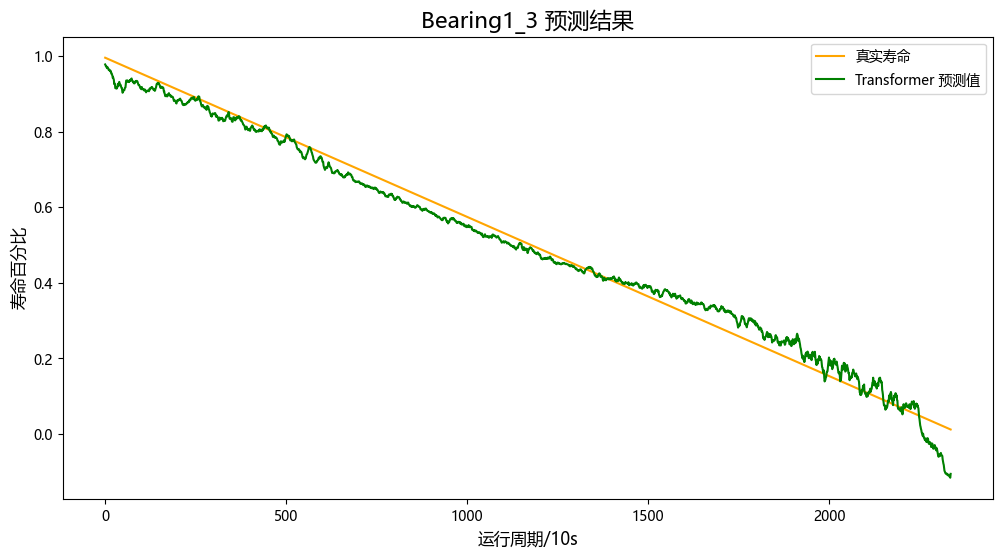

['../画图对比/transformer_pre']

In [13]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

# 可视化结果
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test_origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(test__pre_data, label='Transformer 预测值',color='green')  # 预测值

# plt.plot([-1,170],[2.0*0.7,2.0*0.7],c='black',lw=1,ls='--')  # 临界点直线  可自己调整位置

plt.xlabel('运行周期/10s', fontsize=12)
plt.ylabel('寿命百分比', fontsize=12)
plt.title('Bearing1_3 预测结果', fontsize=16)  
plt.legend()
plt.show()

# 保存数据
# 保存数据
dump(test_origin_data, '../画图对比/transformer_origin') 
dump(test__pre_data, '../画图对比/transformer_pre') 